In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# Exercício 1: Teorema Central do Limite

Considere o **Teorema Central do Limite (TCL)**. Sejam $X_1, \ldots, X_n$ variáveis aleatórias i.i.d., com média $\mu$ e variância finita $\sigma^2$. Então,

$$
\frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}
\xrightarrow{d}
N(0,1),
$$

quando $n \to \infty$.

O objetivo deste exercício é verificar empiricamente o comportamento descrito pelo TCL para diferentes distribuições e diferentes valores de $n$.

1. Considere as seguintes distribuições para $X$:

   * Uniforme;
   * Bernoulli;
   * Geométrica;
   * Poisson.

   Para cada distribuição, escolha diferentes valores de $n$ e gere $M = 5000$ realizações da variável aleatória

   $$
   Z_n = \frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}.
   $$

   Compare o comportamento da distribuição de $Z_n$ conforme o valor de $n$ aumenta.

In [2]:
def normalizar_amostra(amostra, n, mi, sigma2):
    normal = np.sqrt(n)*(np.mean(amostra,axis=1)-mi)/np.sqrt(sigma2)
    return normal

### Uniforme


In [3]:
n = 1000
M = 5000

In [4]:
amostras_uniformes = np.random.uniform(size=(M,n))
amostra_normalizada = normalizar_amostra(amostras_uniformes, n, 0.5, 1/12)

In [5]:
df = pd.DataFrame(amostras_uniformes)
df

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.972207,0.913235,0.056621,0.696388,0.693944,0.716534,0.641216,0.209401,0.868347,0.247630,...,0.684181,0.235832,0.261590,0.580687,0.749679,0.190322,0.107423,0.335916,0.579611,0.114634
1,0.072184,0.737238,0.944927,0.842733,0.354364,0.660721,0.030235,0.214707,0.161135,0.521069,...,0.278558,0.646561,0.799891,0.045511,0.060327,0.118425,0.718674,0.730448,0.827707,0.785067
2,0.209356,0.993210,0.919791,0.591635,0.358854,0.011662,0.067907,0.285562,0.422838,0.787184,...,0.654576,0.278886,0.009965,0.732930,0.863472,0.555573,0.706378,0.978550,0.233723,0.368852
3,0.944424,0.203124,0.097379,0.322172,0.857297,0.834064,0.912410,0.452953,0.967821,0.586511,...,0.359809,0.285008,0.860283,0.634762,0.521768,0.243230,0.215046,0.533465,0.644828,0.383536
4,0.232900,0.442349,0.617900,0.387316,0.329778,0.731424,0.347550,0.136691,0.472274,0.656180,...,0.108032,0.935868,0.775691,0.317380,0.314812,0.346116,0.160572,0.873600,0.230074,0.714292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.569526,0.964954,0.901024,0.876214,0.142080,0.005487,0.658731,0.094275,0.462272,0.116097,...,0.079298,0.380686,0.404502,0.086475,0.664864,0.489332,0.202623,0.915502,0.139167,0.207908
4996,0.457501,0.109760,0.855088,0.987605,0.005227,0.976438,0.292977,0.258070,0.886602,0.083216,...,0.877326,0.153717,0.003496,0.560081,0.528632,0.352751,0.998739,0.701298,0.771116,0.113181
4997,0.466720,0.322749,0.122962,0.665291,0.212473,0.705616,0.902110,0.374701,0.602134,0.429928,...,0.543070,0.195598,0.423639,0.266900,0.141722,0.395881,0.964372,0.473550,0.027992,0.762041
4998,0.412841,0.439207,0.912959,0.060332,0.861513,0.242352,0.910944,0.398357,0.364717,0.542663,...,0.477728,0.444705,0.816308,0.724950,0.968770,0.609073,0.698581,0.787010,0.031314,0.297093


(array([   3.,   22.,  141.,  619., 1261., 1482.,  959.,  408.,   94.,
          11.]),
 array([-4.11188565, -3.33813325, -2.56438085, -1.79062845, -1.01687605,
        -0.24312365,  0.53062874,  1.30438114,  2.07813354,  2.85188594,
         3.62563834]),
 <BarContainer object of 10 artists>)

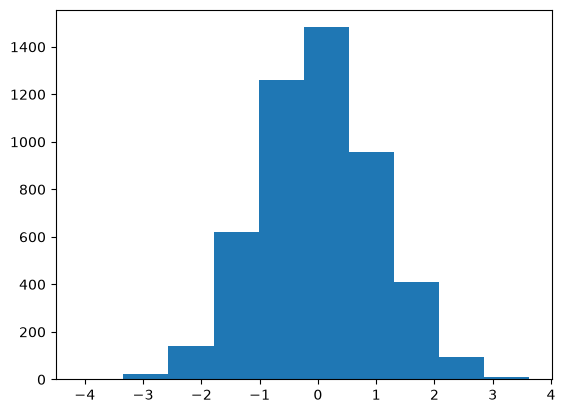

In [6]:
plt.hist(amostra_normalizada)

### Bernoulli

In [7]:
p = 0.5

amostra_bernoulli = amostras_uniformes < p

In [8]:
amostra_normalizada_bernoullis = normalizar_amostra(amostra_bernoulli, n, 0.5, 0.25)

(array([7.000e+00, 5.900e+01, 3.580e+02, 9.560e+02, 1.455e+03, 1.360e+03,
        6.220e+02, 1.530e+02, 2.900e+01, 1.000e+00]),
 array([-3.73148764, -2.94724278, -2.16299792, -1.37875306, -0.5945082 ,
         0.18973666,  0.97398152,  1.75822638,  2.54247124,  3.3267161 ,
         4.11096096]),
 <BarContainer object of 10 artists>)

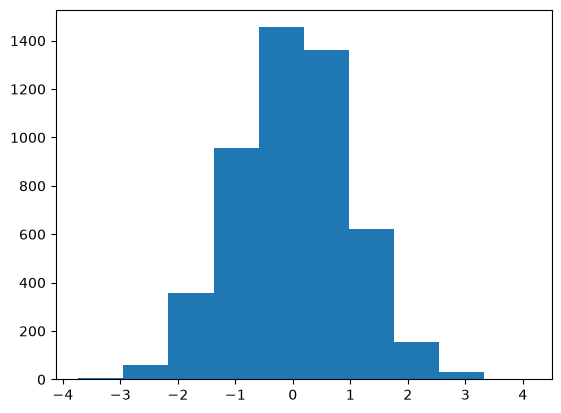

In [9]:
plt.hist(amostra_normalizada_bernoullis)

### Geométrica

In [10]:
p = 0.5
amostras_geometricas = np.floor(np.log(1-amostras_uniformes)/np.log(1-p)) + 1


In [11]:
amostras_geometricas_normalizadas = normalizar_amostra(amostras_geometricas, n, 2, 2)

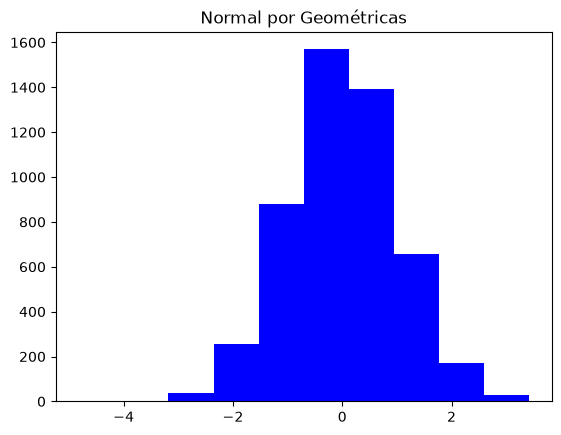

In [12]:
plt.hist(amostras_geometricas_normalizadas, color="blue")
plt.title("Normal por Geométricas")
plt.show()

### Poisson

In [13]:
lmbd = 5
amostras_poisson = []
for _ in tqdm(range(M), desc='Gerando Amostras'):
    amostra_1_poisson = []
    for _ in range(n):
        u = np.random.uniform()
        i = 0
        p0 = np.exp(-lmbd)
        F = p0
        while u > F:
            i += 1
            p0 *= (lmbd/i)
            F += p0
        amostra_1_poisson.append(i)
    amostras_poisson.append(amostra_1_poisson)


Gerando Amostras: 100%|██████████| 5000/5000 [02:19<00:00, 35.83it/s]


(array([  40.,  153.,  460., 1074., 1301., 1126.,  587.,  203.,   48.,
           8.]),
 array([-3.15369624, -2.46780267, -1.78190909, -1.09601551, -0.41012193,
         0.27577164,  0.96166522,  1.6475588 ,  2.33345238,  3.01934596,
         3.70523953]),
 <BarContainer object of 10 artists>)

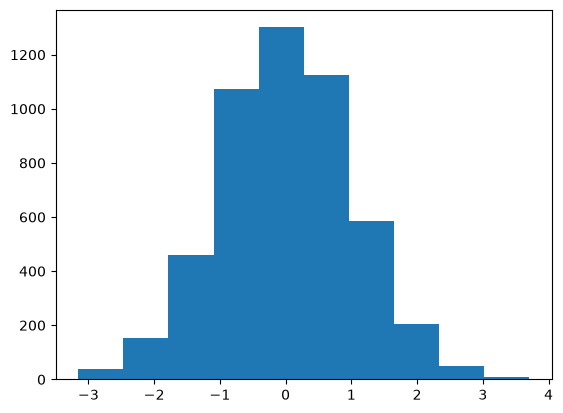

In [14]:
amostra_poisson_normalizada = normalizar_amostra(amostras_poisson, n, 5, 5)
plt.hist(amostra_poisson_normalizada)

2. Para cada distribuição e para cada valor de $n$, construa um histograma das $M = 5000$ realizações de $Z_n$.

   Compare os histogramas obtidos com uma amostra de uma distribuição normal padrão $N(0,1)$ gerada diretamente pelo NumPy.

In [15]:
normais = np.random.normal(0, 1, size=5000)

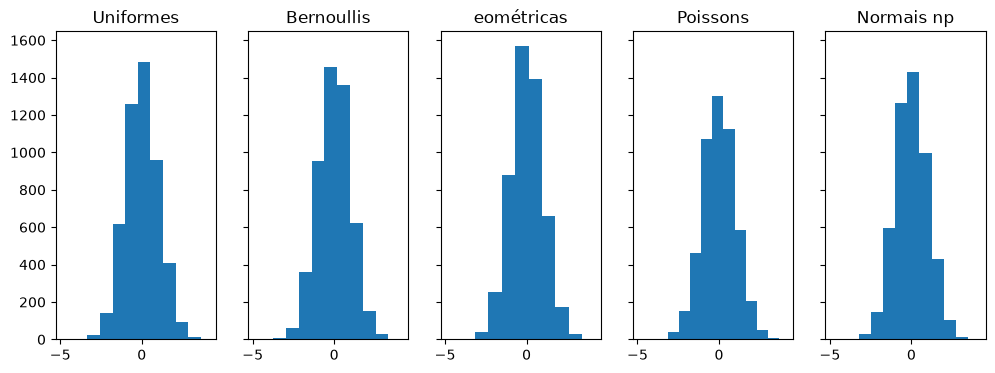

In [16]:
fig, ax = plt.subplots(1,5, figsize= (12,4), sharex=True, sharey=True)

ax[0].hist(amostra_normalizada)
ax[0].set_title('Uniformes')

ax[1].hist(amostra_normalizada_bernoullis)
ax[1].set_title('Bernoullis')

ax[2].hist(amostras_geometricas_normalizadas)
ax[2].set_title('eométricas')

ax[3].hist(amostra_poisson_normalizada)
ax[3].set_title('Poissons')

ax[4].hist(normais)
ax[4].set_title('Normais np')

plt.show()

3. Analise os resultados obtidos e discuta:

   * como a aproximação pela distribuição normal muda conforme $n$ aumenta;
   * quais distribuições apresentam convergência mais rápida para a normal;
   * como o formato da distribuição original influencia a qualidade da aproximação para valores pequenos de $n$.

1- Conforme o n aumenta, as distribuições vão se aproximar cada vez mais da normal(0,1). 
2- A distribuição que converge mais rápido para a Normal é a uniforme, já que ela é simétrica e contínua
3- O formato da dist original influencia a aproximação pois para valores de n pequenos, vai "viesar" o gráfico e se parecer com sua própria forma original

# Exercício 2: Aproximação de Poisson

Como vimos em sala, se$X_n \sim \operatorname{Binomial}(n,p_n),$ com $p_n = \frac{\lambda}{n},$ então, para $\lambda > 0$ fixo,

$$
X_n \xrightarrow{d} \operatorname{Poisson}(\lambda)
$$

quando $n \to \infty$.

Em outras palavras, quando $n$ aumenta e $p_n$ diminui de forma que $np_n = \lambda,$ a distribuição $\operatorname{Binomial}(n,p_n)$ se aproxima de uma distribuição $\operatorname{Poisson}(\lambda)$.

1. Fixe um valor de $\lambda$ e um tamanho de amostra $M$. Para diferentes valores de $n$:

   * defina $p_n = \lambda/n$;
   * gere uma amostra de tamanho $M$ de variáveis

   $$
   X_n \sim \operatorname{Binomial}\left(n,\frac{\lambda}{n}\right);
   $$

   * compare as distribuições obtidas para diferentes valores de $n$ e analise o efeito do aumento de $n$ na aproximação pela distribuição de Poisson.

2. Para verificar a qualidade da aproximação, compare as amostras obtidas pelo método binomial com:

   * uma amostra de tamanho $M$ gerada diretamente por `numpy.random.poisson`;
   * uma amostra de tamanho $M$ de variáveis $\operatorname{Poisson}(\lambda)$ geradas utilizando o **método recursivo**.

3. Para cada método, construa histogramas ou gráficos de frequências e compare as distribuições empíricas obtidas.

4. Compare também o **tempo de execução** dos dois métodos:

   * aproximação por $\operatorname{Binomial}(n,\lambda/n)$;
   * geração de Poisson pelo método da inversão.

In [29]:
def poisson_recursiva(lamb,  M, n):
    p = lamb/n
    poisson = []
    for _ in range(M):
        U = np.random.uniform()
        i = 0
        pi = (1-p)**n
        F = pi
        while U > F:
            pi = (n-i) * p * pi/((i+1) * (1-p))
            i += 1
            F += pi
        poisson.append(i)
    return poisson

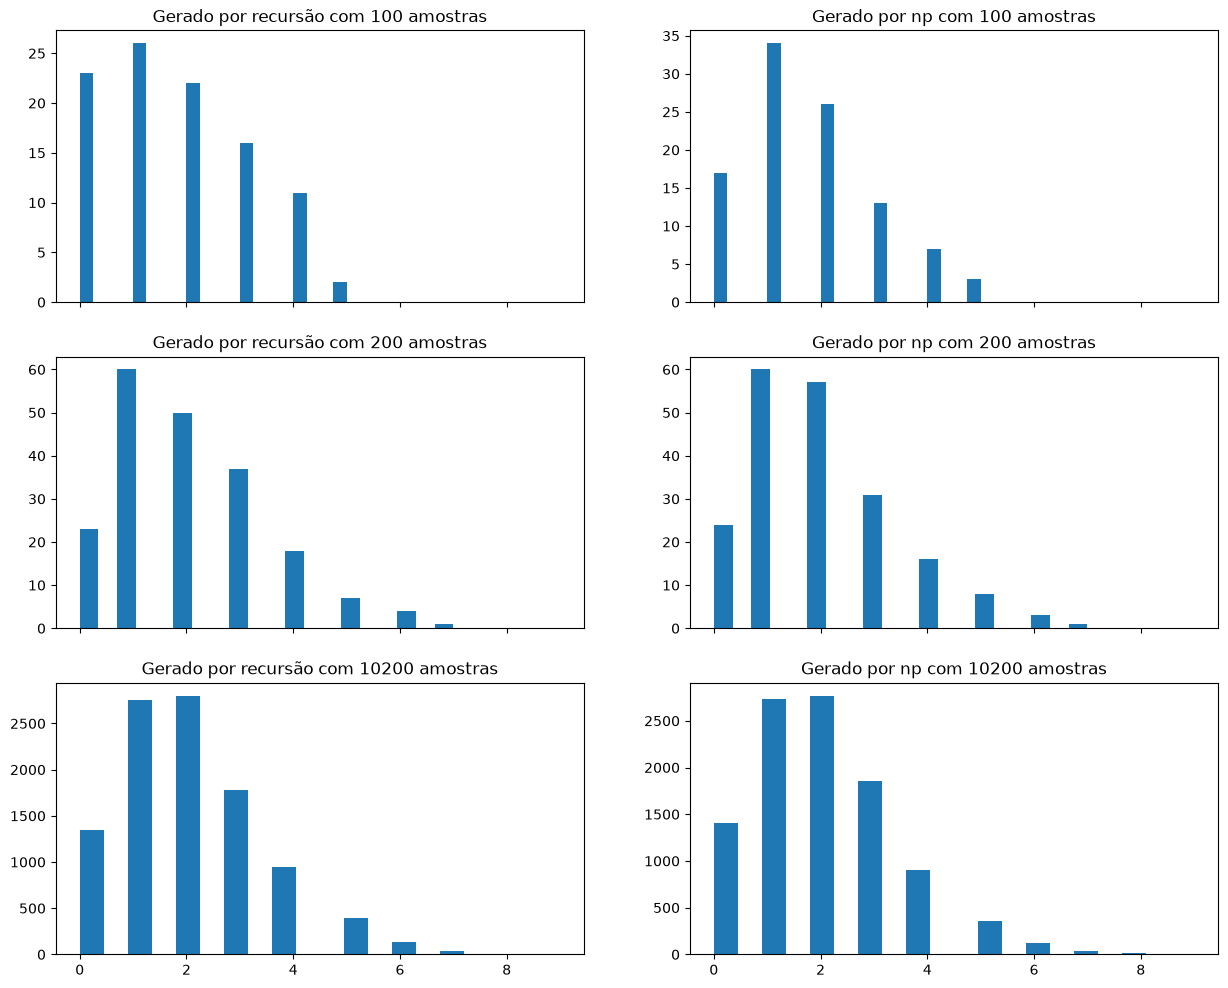

In [30]:
fig, ax = plt.subplots(3,2, figsize=(15,12), sharex= True)
M = 100
lamb = 2
for i in range(3):
    poisson = poisson_recursiva(2, M, n)
    ax[i][0].hist(poisson, bins = 20)
    ax[i][1].hist(np.random.poisson(lamb, size = M), bins = 20)
    ax[i][0].set_title(f'Gerado por recursão com {M} amostras')
    ax[i][1].set_title(f'Gerado por np com {M} amostras')
    M += 100 ** (i + 1)
plt.show()

In [31]:
M = 10_0000
n = 10_000
inicio = time.time()
poisson_recursiva(lamb, M, n)
print(f'Tempo para Poisson por recursao de binomial: {time.time() - inicio:.2f} segundos')

Tempo para Poisson por recursao de binomial: 0.51 segundos


In [ ]:
inicio = time.time()
amostras_poisson = []
for _ in range(M):
    u = np.random.uniform()
    i = 0
    p = np.exp(-lamb) 
    cdf = p
    
    while u > cdf:
        i += 1
        p = p * lamb / i
        cdf += p
    amostras_poisson.append(i)
print(f'Tempo para Poisson por inversa: {time.time() - inicio:.2f} segundos')

5. Discuta os resultados obtidos, considerando:

   * como o valor de $n$ influencia a qualidade da aproximação binomial-Poisson;
   * se as distribuições empíricas produzidas pelos três métodos são semelhantes;
   * as diferenças de tempo de execução entre os métodos;
   * as vantagens e desvantagens de cada método de geração.

A distribuição se assemelha mais da poisson com n grande. A binomial foi a mais rápida, sem considerar a função np. O problema de ambos os métodos é o loop que acaba pesando muito a execução
